

# k Means Facility Location
### OPIM 5641 — Business Decision Modeling · Module4

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5641-notebooks/blob/main/Module4/kMeans_FacilityLocation.ipynb)

*Run me top to bottom — **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

# kMeans Facility Location Algorithm
-----------------------------
**Dr. Dave Wanik - OPIM 5641: Business Decision Modeling - University of Connecticut**

In [38]:
# https://drive.google.com/file/d/1PWTmZOwa_8DPFi80ft3XxUH2U48qmruj/view?usp=sharing
!gdown --id 1PWTmZOwa_8DPFi80ft3XxUH2U48qmruj

Downloading...
From: https://drive.google.com/uc?id=1PWTmZOwa_8DPFi80ft3XxUH2U48qmruj
To: /content/4_AL_CVS_lat_lon.csv
100% 27.6k/27.6k [00:00<00:00, 32.7MB/s]


We can pretend this is an unsupervised learning problem with 2 features (X1 and X2).

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [40]:
df = pd.read_csv('/content/4_AL_CVS_lat_lon.csv')
df.dropna(inplace=True)
df.reset_index(inplace=True)
df # looks like we have 113 stores across Alabama

,index,Unnamed: 0,Address,location,point,latitude,longitude,altitude
0,0,0,"250 S Colonial Dr Alabaster, AL 35007","250, South Colonial Drive, Alabaster Promenade...","(33.22801276687116, -86.80393934355828, 0.0)",33.228013,-86.803939,0.0
1,5,52,"1407 Quintard Ave. Anniston, AL 36201","1407, Quintard Avenue, Anniston, Calhoun Count...","(33.66260384484535, -85.82695609106196, 0.0)",33.662604,-85.826956,0.0
2,6,65,"1204 N. Brindlee Mountain Pkwy. Arab, AL 35016","North Brindlee Mountain Parkway, Arab, Marshal...","(34.3274117, -86.5031572, 0.0)",34.327412,-86.503157,0.0
3,9,104,"333 S College St Auburn, AL 36830","333, South College Street, Auburn, Lee County,...","(32.600466486800244, -85.48167195523679, 0.0)",32.600466,-85.481672,0.0
4,10,105,"1888 Ogletree Road Auburn, AL 36830","1888, Ogletree Road, Bent Brooke, Auburn, Lee ...","(32.58431374828644, -85.4388022319555, 0.0)",32.584314,-85.438802,0.0
...,...,...,...,...,...,...,...,...
108,171,1235,"202 W. Martin Luther King Hwy. Tuskegee, AL 36083","West Martin Luther King Highway, Tuskegee, Mac...","(32.414374, -85.703086, 0.0)",32.414374,-85.703086,0.0
109,173,1261,"2480 Rocky Ridge Road Vestavia, AL 35243","2480, Rocky Ridge Road, Ivy Glenn, Vestavia Hi...","(33.421398, -86.77236266666667, 0.0)",33.421398,-86.772363,0.0
110,174,1274,"4197 Crosshaven Dr. Vestavia Hills, AL 35243","4197, Crosshaven Drive, Overton Manor, Welling...","(33.455419, -86.73081, 0.0)",33.455419,-86.730810,0.0
111,175,1275,"1100 Montgomery Hwy. Vestavia Hills, AL 35216","Montgomery Highway, Montreat, Vestavia Hills, ...","(33.4225501, -86.7975161, 0.0)",33.422550,-86.797516,0.0


# Make a map of the store locations

Longitude is the X axis, and Latitude is Y axis. See if you can make a nice plot.

In [41]:
import folium as folium
map1 = folium.Map(
    location=[30, -86], # lat lon of alabama!
    tiles='cartodbpositron',
    zoom_start=5,
)
df.apply(lambda row:folium.CircleMarker(location=[row["latitude"], row["longitude"]]).add_to(map1), axis=1)
map1

# kMeans clustering
Using lat/lon data is an effecient way for use to nonlinearly where to place more than one location.

When we have one location, we can solve the distance explicitly and optimally. When there is one than more than one location to model, the problem gets much more difficult to solve because it involves binary 'activation variables'. 

For now we can leverage kMeans clustering which will mimic the spirit of what we tried to do with one location.

From sklearn documentation:

> The KMeans algorithm clusters data by trying to separate samples in n groups of equal variance, minimizing a criterion known as the inertia or within-cluster sum-of-squares (see below). This algorithm requires the number of clusters to be specified. It scales well to large number of samples and has been used across a large range of application areas in many different fields.

> $\sum_{i=0}^{n}\min_{\mu_j \in C}(||x_i - \mu_j||^2)$

> K-means is often referred to as Lloyd’s algorithm. In basic terms, the algorithm has three steps. The first step chooses the initial centroids, with the most basic method being to choose $k$ samples from the dataset $X$. After initialization, K-means consists of looping between the two other steps. The first step assigns each sample to its nearest centroid. The second step creates new centroids by taking the mean value of all of the samples assigned to each previous centroid. The difference between the old and the new centroids are computed and the algorithm repeats these last two steps until this value is less than a threshold. In other words, it repeats until the centroids do not move significantly.

How does it work? Look at the images here:
* https://en.wikipedia.org/wiki/K-means_clustering

1. k initial "means" (in this case k=3) are randomly generated within the data domain (shown in color).

<center>

![Figure 1](https://upload.wikimedia.org/wikipedia/commons/5/5e/K_Means_Example_Step_1.svg)

</center>

2. k clusters are created by associating every observation with the nearest mean. The partitions here represent the Voronoi diagram generated by the means.


<center>

![Figure 2](https://upload.wikimedia.org/wikipedia/commons/a/a5/K_Means_Example_Step_2.svg)

</center>

3. The centroid of each of the k clusters becomes the new mean.


<center>

![Figure 3](https://upload.wikimedia.org/wikipedia/commons/3/3e/K_Means_Example_Step_3.svg)

</center>

 

4. Steps 2 and 3 are repeated until convergence has been reached.



<center>

![Figure 4](https://upload.wikimedia.org/wikipedia/commons/d/d2/K_Means_Example_Step_4.svg)

</center>

Of course there are potential drawbacks - that you might end up with elongated clusters if not careful. There are MANY other interesting clustering algorithms that you can pull of the shelf (which are more sophisticated than kMeans but are totally awesome. Read up on your own!)

Notice that lat/lon coordinates are not appropriate in raw form - this is because we are in degrees of latitude and longitude (which have a unit of degrees!) Let's convert to a more useful projection (meters) so that distance calculations are more accurate. 

This requires us to use `geopandas` - an amazing geospatial library that's similar to `pandas`, but for geographic data.

# Convert to meters

In [42]:
!pip install geopandas

In [43]:
import geopandas as gpd

Here is where you can get a nice basemap - later on we can try to overlay our points on this map (static, not HTML like `folium`):
* https://geopandas.org/en/stable/docs/user_guide/mapping.html

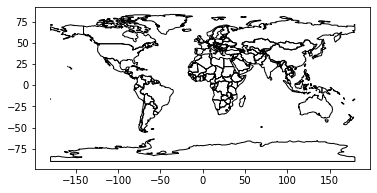

In [44]:
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world.plot(color='none', # fill color
           edgecolor='black') # edge color
plt.show()

Let's see if we can overlay our points onto the map.

In [45]:
# see how the epsg is 4326? the units are DEGREES!
# improper for a distance calculation
world.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

You can use `epsg 3857` instead! A Mercator projection in meters. Look at the difference of how this 'version' of the World looks vs. others.

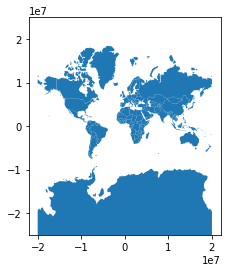

In [46]:
world.to_crs(epsg=3857, inplace=True)
# see the world at the very top? :)
world.plot() 
plt.ylim([-0.25E8,0.25E8])
plt.show()

Let's convert our point data to a shapefile, assign it a CRS (lat/lon), then convert it to meters.

In [47]:
from geopandas import GeoDataFrame
from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(df.longitude, df.latitude)]
crs = {'init': 'epsg:4326'} #http://www.spatialreference.org/ref/epsg/2263/
geo_df = gpd.GeoDataFrame(df, crs=crs, geometry=geometry)

/usr/local/lib/python3.7/dist-packages/pyproj/crs/crs.py:131: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


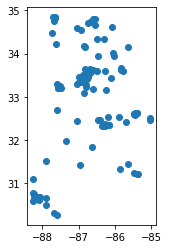

In [48]:
# doesn't this look like alabama? A little nicer.
geo_df.plot()
plt.show()

But as you will see - this crs is in degrees... we need to be in meters before running kMeans.

In [49]:
geo_df.crs

<Geographic 2D CRS: +init=epsg:4326 +type=crs>
Name: WGS 84
Axis Info [ellipsoidal]:
- lon[east]: Longitude (degree)
- lat[north]: Latitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Let's reproject to meters!

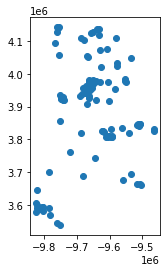

In [50]:
geo_df.to_crs(epsg=3857, inplace=True)
geo_df.plot() # see how the units on the axes is different?
              # it is in meters
plt.show()

Now check your work to get the coordinates. If you look at the geometry column you will notice that your new coordinates in METERS are there. Let's extract them so that it's easy to fit k-means.

In [51]:
geo_df

,index,Unnamed: 0,Address,location,point,latitude,longitude,altitude,geometry
0,0,0,"250 S Colonial Dr Alabaster, AL 35007","250, South Colonial Drive, Alabaster Promenade...","(33.22801276687116, -86.80393934355828, 0.0)",33.228013,-86.803939,0.0,POINT (-9662970.327 3925608.100)
1,5,52,"1407 Quintard Ave. Anniston, AL 36201","1407, Quintard Avenue, Anniston, Calhoun Count...","(33.66260384484535, -85.82695609106196, 0.0)",33.662604,-85.826956,0.0,POINT (-9554213.048 3983587.441)
2,6,65,"1204 N. Brindlee Mountain Pkwy. Arab, AL 35016","North Brindlee Mountain Parkway, Arab, Marshal...","(34.3274117, -86.5031572, 0.0)",34.327412,-86.503157,0.0,POINT (-9629487.412 4072850.604)
3,9,104,"333 S College St Auburn, AL 36830","333, South College Street, Auburn, Lee County,...","(32.600466486800244, -85.48167195523679, 0.0)",32.600466,-85.481672,0.0,POINT (-9515776.194 3842391.858)
4,10,105,"1888 Ogletree Road Auburn, AL 36830","1888, Ogletree Road, Bent Brooke, Auburn, Lee ...","(32.58431374828644, -85.4388022319555, 0.0)",32.584314,-85.438802,0.0,POINT (-9511003.958 3840257.658)
...,...,...,...,...,...,...,...,...,...
108,171,1235,"202 W. Martin Luther King Hwy. Tuskegee, AL 36083","West Martin Luther King Highway, Tuskegee, Mac...","(32.414374, -85.703086, 0.0)",32.414374,-85.703086,0.0,POINT (-9540423.893 3817827.408)
109,173,1261,"2480 Rocky Ridge Road Vestavia, AL 35243","2480, Rocky Ridge Road, Ivy Glenn, Vestavia Hi...","(33.421398, -86.77236266666667, 0.0)",33.421398,-86.772363,0.0,POINT (-9659455.227 3951372.010)
110,174,1274,"4197 Crosshaven Dr. Vestavia Hills, AL 35243","4197, Crosshaven Drive, Overton Manor, Welling...","(33.455419, -86.73081, 0.0)",33.455419,-86.730810,0.0,POINT (-9654829.605 3955910.413)
111,175,1275,"1100 Montgomery Hwy. Vestavia Hills, AL 35216","Montgomery Highway, Montreat, Vestavia Hills, ...","(33.4225501, -86.7975161, 0.0)",33.422550,-86.797516,0.0,POINT (-9662255.294 3951525.671)


Here is how to extract the centroid of any point, line or polygon once it is a geodataframe:
* https://stackoverflow.com/questions/60922709/turn-geometry-column-into-lat-long-columns-in-geodataframe

In [52]:
geo_df['lon_m'] = geo_df.geometry.apply(lambda p: p.x)
geo_df['lat_m'] = geo_df.geometry.apply(lambda p: p.y)
geo_df.head() # check your work

,index,Unnamed: 0,Address,location,point,latitude,longitude,altitude,geometry,lon_m,lat_m
0,0,0,"250 S Colonial Dr Alabaster, AL 35007","250, South Colonial Drive, Alabaster Promenade...","(33.22801276687116, -86.80393934355828, 0.0)",33.228013,-86.803939,0.0,POINT (-9662970.327 3925608.100),-9.662970e+06,3.925608e+06
1,5,52,"1407 Quintard Ave. Anniston, AL 36201","1407, Quintard Avenue, Anniston, Calhoun Count...","(33.66260384484535, -85.82695609106196, 0.0)",33.662604,-85.826956,0.0,POINT (-9554213.048 3983587.441),-9.554213e+06,3.983587e+06
2,6,65,"1204 N. Brindlee Mountain Pkwy. Arab, AL 35016","North Brindlee Mountain Parkway, Arab, Marshal...","(34.3274117, -86.5031572, 0.0)",34.327412,-86.503157,0.0,POINT (-9629487.412 4072850.604),-9.629487e+06,4.072851e+06
3,9,104,"333 S College St Auburn, AL 36830","333, South College Street, Auburn, Lee County,...","(32.600466486800244, -85.48167195523679, 0.0)",32.600466,-85.481672,0.0,POINT (-9515776.194 3842391.858),-9.515776e+06,3.842392e+06
4,10,105,"1888 Ogletree Road Auburn, AL 36830","1888, Ogletree Road, Bent Brooke, Auburn, Lee ...","(32.58431374828644, -85.4388022319555, 0.0)",32.584314,-85.438802,0.0,POINT (-9511003.958 3840257.658),-9.511004e+06,3.840258e+06


OK - you are ready to rock now! Just subset `lat_m` and `lon_m` and you are ready to rock.

# $k=2$

As the analyst, you get to choose what $k$ is - the simplest thing to do is to use $k=2$ but eventually you can use any value and see what you get. Remember, due to the randomness of the algorithm, you may end up with different results if you run it 10 times and plot the answer (more on that soon).

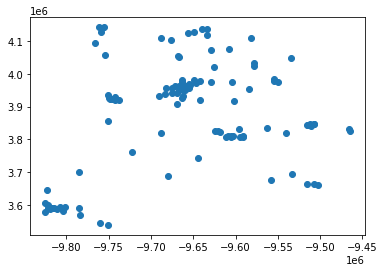

In [53]:
from sklearn.cluster import KMeans
import numpy as np
X = geo_df[['lon_m', 'lat_m']]
plt.scatter(x=X['lon_m'], y=X['lat_m'])
plt.show()

In [54]:
kmeans = KMeans(n_clusters=2, random_state=0).fit(X)

# this is the label of the 'centroid' that corresponds to each point
print('labelAssignment to Stores:', kmeans.labels_)
print('geogCoords of the k facilities:', kmeans.cluster_centers_)
print('SSE (intertia) of each cluster:', kmeans.inertia_)

labelAssignment to Stores: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]
geogCoords of the k facilities: [[-9639546.57904747  3952505.30553302]
 [-9732798.50471264  3625109.95777365]]
SSE (intertia) of each cluster: 1737587016384.059


We can add these labels back to the geodataframe to 'color by group' (or category) and make a nice map to check our work.

In [55]:
geo_df['clusterLabel'] = kmeans.labels_

In [56]:
# convert the two points to geodataframes and add them to the plot
theWarehouses = kmeans.cluster_centers_
theWarehouses = pd.DataFrame(theWarehouses)
theWarehouses

,0,1
0,-9.639547e+06,3.952505e+06
1,-9.732799e+06,3.625110e+06


In [57]:
# rename columns for ease
theWarehouses.rename(columns={0:'lon_m', 1:'lat_m'}, inplace=True)

We will recycle some code from above for clarity.

In [58]:
from geopandas import GeoDataFrame
from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(theWarehouses['lon_m'], theWarehouses['lat_m'])]
crs = {'init': 'epsg:3857'} #our data is already in meters!
theWarehouses = gpd.GeoDataFrame(theWarehouses, crs=crs, geometry=geometry)

/usr/local/lib/python3.7/dist-packages/pyproj/crs/crs.py:131: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


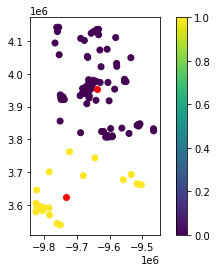

In [59]:
ax = geo_df.plot(column='clusterLabel', legend=True)
theWarehouses.plot(ax=ax, color='red')
plt.show()

# $k=5$
It is ALL the same code - but I made `n_clusters=5`

In [60]:
kmeans = KMeans(n_clusters=5, random_state=0).fit(X)

# this is the label of the 'centroid' that corresponds to each point
print('labelAssignment to Stores:', kmeans.labels_)
print('geogCoords of the k facilities:', kmeans.cluster_centers_)

labelAssignment to Stores: [0 0 4 2 2 2 2 0 0 0 0 0 0 0 0 2 0 4 1 0 4 4 4 4 3 3 3 3 1 1 4 4 4 0 0 0 0
 2 1 4 4 0 0 0 0 0 0 4 4 4 4 1 4 0 0 1 1 1 1 1 1 1 1 1 1 0 2 2 2 2 2 2 2 2
 0 0 4 0 0 0 2 2 1 0 0 3 0 0 2 2 2 2 2 0 4 4 2 1 1 0 0 2 0 0 0 0 0 0 2 0 0
 0 2]
geogCoords of the k facilities: [[-9660861.90224452  3953890.72106655]
 [-9796453.95684474  3598162.70458546]
 [-9577151.74657951  3818937.77813702]
 [-9523377.74762964  3671171.83363382]
 [-9674661.0760476   4103842.65042381]]


We can add these labels back to the geodataframe to 'color by group' (or category) and make a nice map to check our work.

In [61]:
geo_df['clusterLabel'] = kmeans.labels_

In [62]:
# convert the two points to geodataframes and add them to the plot
theWarehouses = kmeans.cluster_centers_
theWarehouses = pd.DataFrame(theWarehouses)
theWarehouses

,0,1
0,-9.660862e+06,3.953891e+06
1,-9.796454e+06,3.598163e+06
2,-9.577152e+06,3.818938e+06
3,-9.523378e+06,3.671172e+06
4,-9.674661e+06,4.103843e+06


In [63]:
# rename columns for ease
theWarehouses.rename(columns={0:'lon_m', 1:'lat_m'}, inplace=True)

We will recycle some code from above for clarity.

In [64]:
from geopandas import GeoDataFrame
from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(theWarehouses['lon_m'], theWarehouses['lat_m'])]
crs = {'init': 'epsg:3857'} #our data is already in meters!
theWarehouses = gpd.GeoDataFrame(theWarehouses, crs=crs, geometry=geometry)

/usr/local/lib/python3.7/dist-packages/pyproj/crs/crs.py:131: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


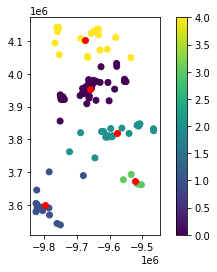

In [65]:
ax = geo_df.plot(column='clusterLabel', legend=True)
theWarehouses.plot(ax=ax, color='red')
plt.show()

This legend is OK - but it really shouldn't be continuous... should be discrete entries!

What do you see? Some clusters are very big and some are very small. Some are quite round and some are quite elongated.

# Make a nice map in `folium` of your results

The HTML map really looks much nicer than the static plt maps, but the downside is that these maps can be tough to show in a meeting.

In [66]:
# on your own!

# k in a for loop
... do you get different results?

This is a beautiful article - you can hack some of the code and see how you can get slightly different results each time you run the model. You will also see the 'elbow method' for selecting the 'optimal' number of records from a 'scree plot' (y = SSE interia vs. X = number of clusters).

From Wikipedia...

<center>

![link text](https://upload.wikimedia.org/wikipedia/commons/e/ea/K-means_convergence.gif)

</center>

# Try incorporating a sample weight ($k=5$)
This could be the population of the customer base served at an existing store location. `sample_weight` is the argument and has the same effect of duplicating a row (you can try this!!!)

I could be much more elegant here - but for now, I will just put in a random number - this should cause the locations of the facilities to shift! You can imagine it is the number of deliveries required each week (due to demand).

In [67]:
geo_df['Deliveries'] = np.random.normal(loc=1000, scale=200, size=np.shape(geo_df)[0])
geo_df.head()

,index,Unnamed: 0,Address,location,point,latitude,longitude,altitude,geometry,lon_m,lat_m,clusterLabel,Deliveries
0,0,0,"250 S Colonial Dr Alabaster, AL 35007","250, South Colonial Drive, Alabaster Promenade...","(33.22801276687116, -86.80393934355828, 0.0)",33.228013,-86.803939,0.0,POINT (-9662970.327 3925608.100),-9.662970e+06,3.925608e+06,0,792.619370
1,5,52,"1407 Quintard Ave. Anniston, AL 36201","1407, Quintard Avenue, Anniston, Calhoun Count...","(33.66260384484535, -85.82695609106196, 0.0)",33.662604,-85.826956,0.0,POINT (-9554213.048 3983587.441),-9.554213e+06,3.983587e+06,0,1207.109360
2,6,65,"1204 N. Brindlee Mountain Pkwy. Arab, AL 35016","North Brindlee Mountain Parkway, Arab, Marshal...","(34.3274117, -86.5031572, 0.0)",34.327412,-86.503157,0.0,POINT (-9629487.412 4072850.604),-9.629487e+06,4.072851e+06,4,861.736367
3,9,104,"333 S College St Auburn, AL 36830","333, South College Street, Auburn, Lee County,...","(32.600466486800244, -85.48167195523679, 0.0)",32.600466,-85.481672,0.0,POINT (-9515776.194 3842391.858),-9.515776e+06,3.842392e+06,2,1113.464236
4,10,105,"1888 Ogletree Road Auburn, AL 36830","1888, Ogletree Road, Bent Brooke, Auburn, Lee ...","(32.58431374828644, -85.4388022319555, 0.0)",32.584314,-85.438802,0.0,POINT (-9511003.958 3840257.658),-9.511004e+06,3.840258e+06,2,991.471336


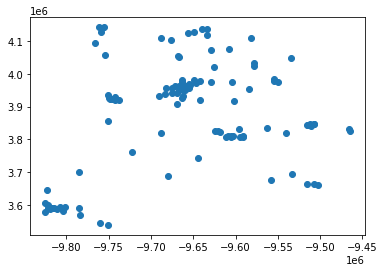

In [68]:
from sklearn.cluster import KMeans
import numpy as np
X = geo_df[['lon_m', 'lat_m', 'Deliveries']]
plt.scatter(x=X['lon_m'], y=X['lat_m'])
plt.show()

In [69]:
kmeans = KMeans(n_clusters=5, random_state=0).fit(X[['lon_m', 'lat_m']], sample_weight=X['Deliveries'])

# this is the label of the 'centroid' that corresponds to each point
print('labelAssignment to Stores:', kmeans.labels_)
print('geogCoords of the k facilities:', kmeans.cluster_centers_)
print('SSE (intertia) of each cluster:', kmeans.inertia_)

labelAssignment to Stores: [2 4 0 3 3 3 3 2 2 2 2 2 2 2 2 3 2 4 1 2 0 0 0 0 3 3 3 3 1 1 0 0 0 2 4 2 2
 3 1 4 0 2 2 2 2 2 2 0 0 0 0 1 0 2 2 1 1 1 1 1 1 1 1 1 1 2 3 3 3 3 3 3 3 3
 2 2 0 2 2 4 3 3 1 4 4 3 2 4 3 3 3 3 3 4 0 4 2 1 1 2 4 3 2 2 2 2 2 2 3 2 2
 2 3]
geogCoords of the k facilities: [[-9688310.79546214  4107595.84501057]
 [-9794037.56739008  3596036.16678623]
 [-9676576.97391679  3944602.36573296]
 [-9560314.86960509  3795207.19380899]
 [-9574120.01008908  4014980.94771313]]
SSE (intertia) of each cluster: 426807333442692.75


We can add these labels back to the geodataframe to 'color by group' (or category) and make a nice map to check our work.

In [70]:
geo_df['clusterLabel'] = kmeans.labels_

In [71]:
# convert the two points to geodataframes and add them to the plot
theWarehouses = kmeans.cluster_centers_
theWarehouses = pd.DataFrame(theWarehouses)
theWarehouses

,0,1
0,-9.688311e+06,4.107596e+06
1,-9.794038e+06,3.596036e+06
2,-9.676577e+06,3.944602e+06
3,-9.560315e+06,3.795207e+06
4,-9.574120e+06,4.014981e+06


In [72]:
# rename columns for ease
theWarehouses.rename(columns={0:'lon_m', 1:'lat_m'}, inplace=True)

We will recycle some code from above for clarity.

In [73]:
from geopandas import GeoDataFrame
from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(theWarehouses['lon_m'], theWarehouses['lat_m'])]
crs = {'init': 'epsg:3857'} #our data is already in meters!
theWarehouses = gpd.GeoDataFrame(theWarehouses, crs=crs, geometry=geometry)

/usr/local/lib/python3.7/dist-packages/pyproj/crs/crs.py:131: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


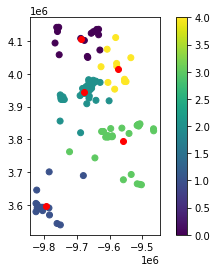

In [74]:
ax = geo_df.plot(column='clusterLabel', legend=True)
theWarehouses.plot(ax=ax, color='red')
plt.show()

This plot is way different than the k=5 above... all due to the weighting!

If you make mean 10000 and the sd 3000, it will be a huge difference!

# Trying a different clustering algorithm


If you try DBSCAN with $k=5$ what do you get? What is the limit of the DBSCAN algorithm?